<a href="https://colab.research.google.com/github/filfish2007-cav/ITStep-AI/blob/superwised_learning/%D0%94%D0%97_%D0%BE%D0%B1%D1%80%D0%BE%D0%B1%D0%BA%D0%B0_%D0%B4%D0%B0%D0%BD%D0%B8%D1%85(%D1%85%D0%B0%D1%82%D0%B8).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.tree import DecisionTreeRegressor

In [4]:
df = pd.read_csv("https://raw.githubusercontent.com/HalyshAnton/IT-Step-Pyton-AI/main/module3/data/House_Rent_Dataset.csv", index_col="Unnamed: 0")

[Інформація про дані](https://www.kaggle.com/datasets/iamsouravbanerjee/house-rent-prediction-dataset)

In [5]:
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2.0,10000.0,1100.0,Ground out of 2,NaN,NaN,Kolkata,Unfurnished,Bachelors/Family,2.0,Contact Owner
1,2022-05-13,2.0,20000.0,800.0,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1.0,NaN
2,2022-05-16,2.0,17000.0,1000.0,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1.0,Contact Owner
3,2022-07-04,2.0,10000.0,800.0,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1.0,Contact Owner
4,NaN,2.0,7500.0,850.0,1 out of 2,Carpet Area,NaN,Kolkata,Unfurnished,Bachelors,1.0,Contact Owner


# Завдання 1
Виведіть інформацію про таблицю(кількість рядків та стовпчиків та типи даних). Також виведіть кількість пропущених значень по стовпчиках

In [6]:
df.info()
display(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Posted On          4379 non-null   object 
 1   BHK                4342 non-null   float64
 2   Rent               4369 non-null   float64
 3   Size               4402 non-null   float64
 4   Floor              4380 non-null   object 
 5   Area Type          4390 non-null   object 
 6   Area Locality      4347 non-null   object 
 7   City               4388 non-null   object 
 8   Furnishing Status  4395 non-null   object 
 9   Tenant Preferred   4372 non-null   object 
 10  Bathroom           4387 non-null   float64
 11  Point of Contact   4372 non-null   object 
dtypes: float64(4), object(8)
memory usage: 611.1+ KB


,0
Posted On,367
BHK,404
Rent,377
Size,344
Floor,366
Area Type,356
Area Locality,399
City,358
Furnishing Status,351
Tenant Preferred,374


# Завдання 2
Виведіть гістограми для всіх числових стовпчиків

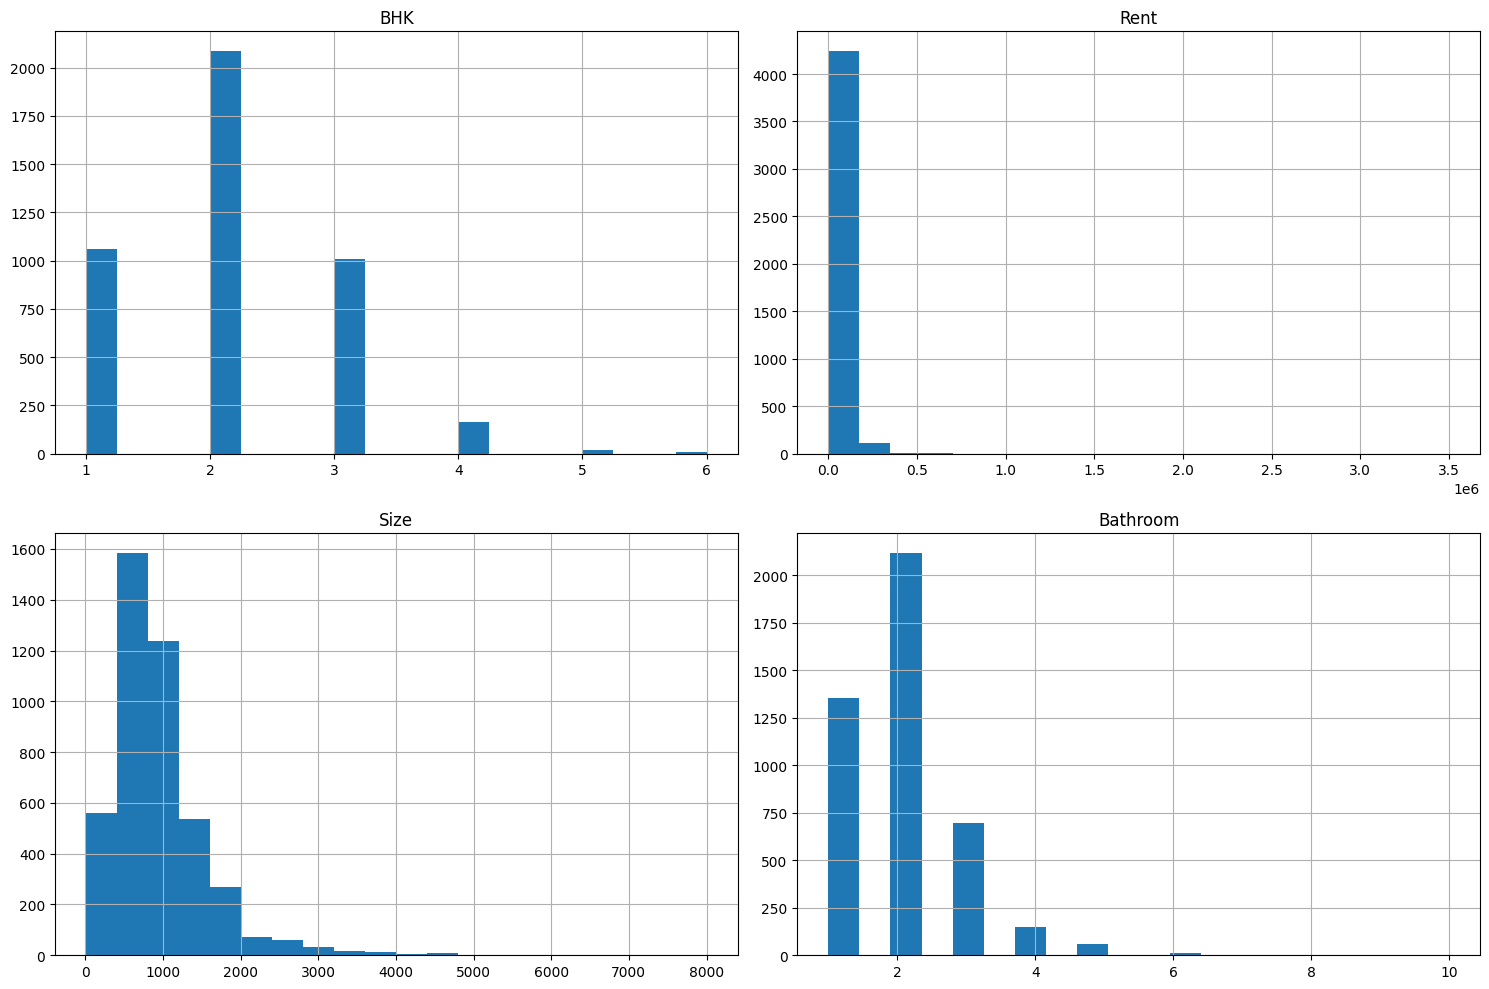

In [7]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Створюємо гістограми
df[numerical_cols].hist(bins=20, figsize=(15, 10))
plt.tight_layout()
plt.show()

# Завдання 3
Виведіть ящик з вусами для всіх числових стовпчиків. Де потрібно очистіть викиди

In [8]:
mask = df['BHK'] < 0.3 * 1e6
mask.sum()



np.int64(4342)

In [9]:
df = df[mask]

<Axes: >

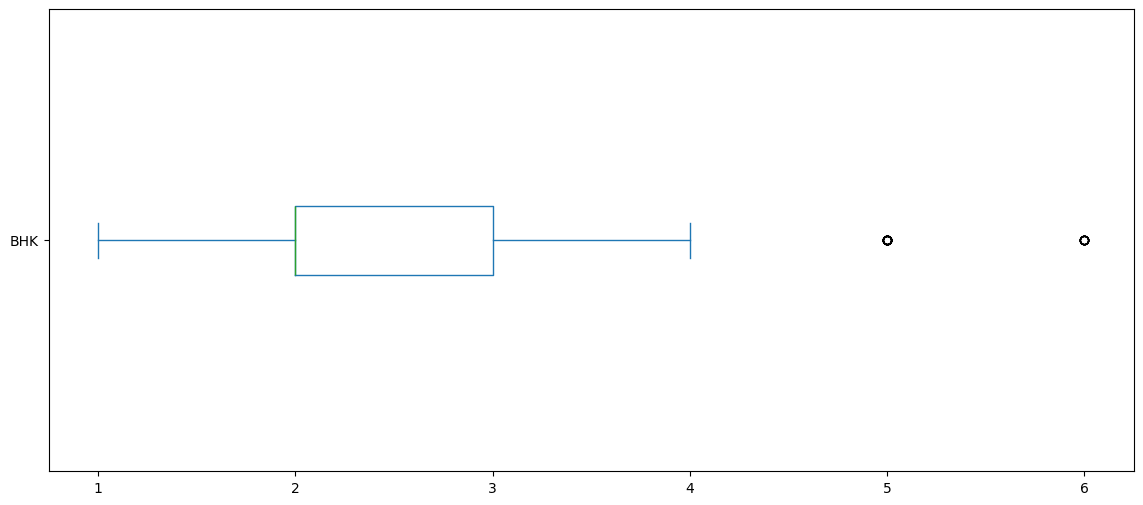

In [10]:
df['BHK'].plot(kind='box', vert=False,figsize=(14,6))

In [11]:
mask = df['Rent'] <= 280000
mask.sum()



np.int64(3954)

In [12]:
df = df[mask]

count      3954.000000
mean      29748.483055
std       38547.219064
min        1200.000000
25%       10000.000000
50%       16000.000000
75%       32000.000000
90%       65000.000000
95%      100000.000000
99%      200000.000000
max      280000.000000
Name: Rent, dtype: float64


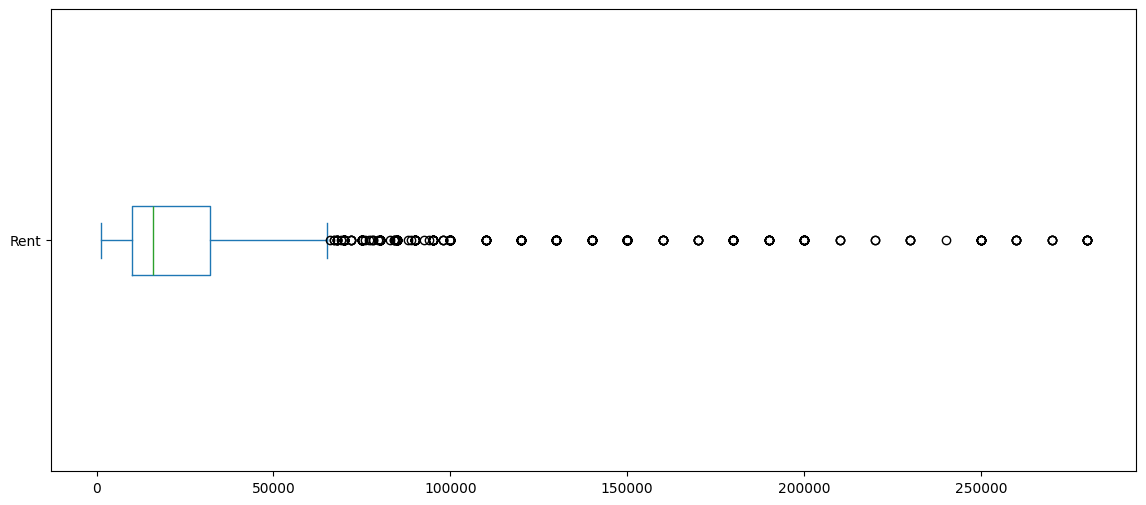

In [13]:
df['Rent'].plot(kind='box', vert=False,figsize=(14,6))
# Смотрим на текстовое описание распределения
print(df['Rent'].describe(percentiles=[0.25,0.5, 0.75, 0.9, 0.95, 0.99]))


In [14]:
mask = df['Size'] <= 3137
mask.sum()



np.int64(3640)

In [15]:
df = df[mask]

count    3640.000000
mean      919.287088
std       511.303031
min        10.000000
25%       550.000000
50%       841.500000
75%      1200.000000
90%      1600.000000
95%      1851.100000
99%      2600.000000
max      3133.000000
Name: Size, dtype: float64


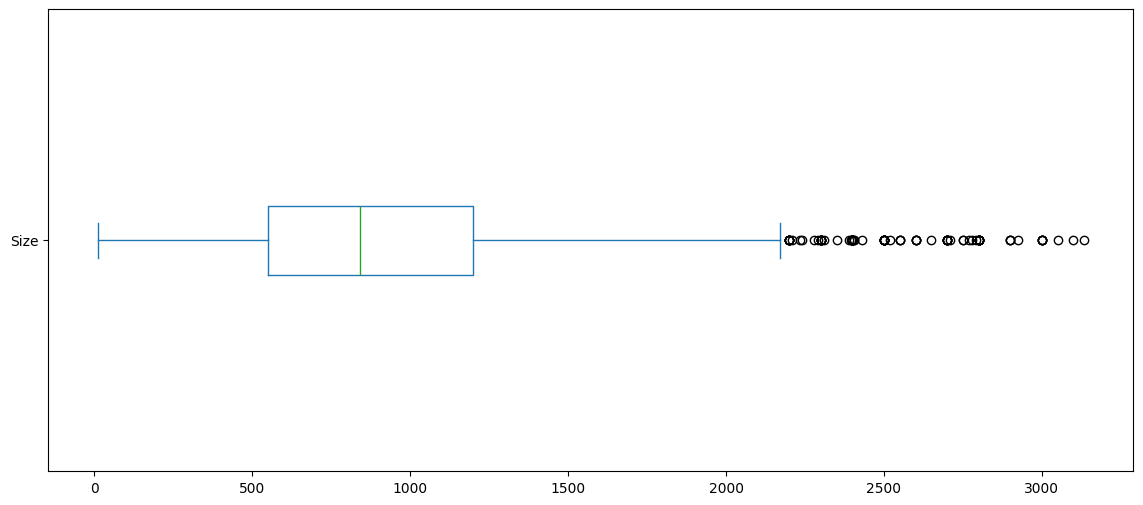

In [16]:
df['Size'].plot(kind='box', vert=False,figsize=(14,6))
print(df['Size'].describe(percentiles=[0.25,0.5, 0.75, 0.9, 0.95, 0.99]))

In [17]:
mask = df['Bathroom'] <= 4
mask.sum()



np.int64(3330)

In [18]:
df = df[mask]

count    3330.000000
mean        1.891892
std         0.750904
min         1.000000
25%         1.000000
50%         2.000000
75%         2.000000
90%         3.000000
95%         3.000000
99%         4.000000
max         4.000000
Name: Bathroom, dtype: float64


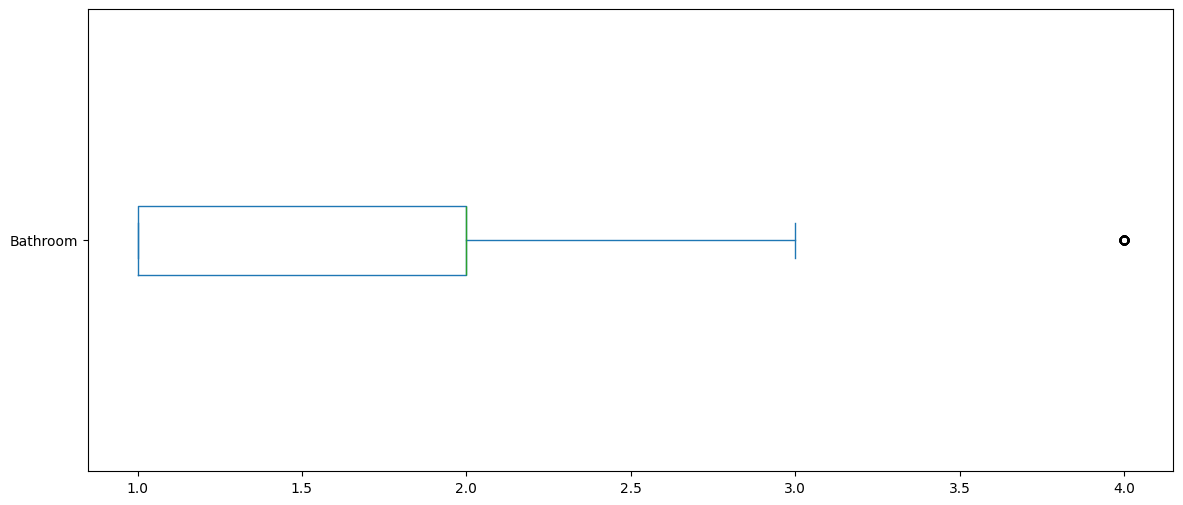

In [19]:
df['Bathroom'].plot(kind='box', vert=False,figsize=(14,6))
print(df['Bathroom'].describe(percentiles=[0.25,0.5, 0.75, 0.9, 0.95, 0.99]))

# Завдання 4
Створіть Pipeline для обробки даних

In [20]:
X = df.drop('Rent', axis=1)  # Features
y = df['Rent']  # Target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (2664, 11)
X_test shape: (666, 11)
y_train shape: (2664,)
y_test shape: (666,)


In [22]:


# Визначення числових та категоріальних колонок
num_features = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_features = X_train.select_dtypes(include=['object', 'category']).columns

# Пайплайн для числових даних
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Пайплайн для категоріальних даних
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])

# Об'єднання в один препроцесор
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

# Застосування до тренувальних та тестових даних
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

In [23]:
preprocessor.set_output(transform="pandas")

# 3. Трансформація даних
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

# 4. Налаштування гарного виводу в консоль
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [24]:
X_train_prepared

num__BHK  num__Size  num__Bathroom  cat__Posted On_2022-04-23  cat__Posted On_2022-04-24  cat__Posted On_2022-04-25  cat__Posted On_2022-04-26  cat__Posted On_2022-04-27  cat__Posted On_2022-04-28  cat__Posted On_2022-04-29  cat__Posted On_2022-04-30  cat__Posted On_2022-05-01  cat__Posted On_2022-05-02  cat__Posted On_2022-05-03  cat__Posted On_2022-05-04  cat__Posted On_2022-05-05  cat__Posted On_2022-05-06  cat__Posted On_2022-05-07  cat__Posted On_2022-05-08  cat__Posted On_2022-05-09  cat__Posted On_2022-05-10  cat__Posted On_2022-05-11  cat__Posted On_2022-05-12  cat__Posted On_2022-05-13  cat__Posted On_2022-05-14  cat__Posted On_2022-05-15  cat__Posted On_2022-05-16  cat__Posted On_2022-05-17  cat__Posted On_2022-05-18  cat__Posted On_2022-05-19  cat__Posted On_2022-05-20  cat__Posted On_2022-05-21  cat__Posted On_2022-05-22  cat__Posted On_2022-05-23  cat__Posted On_2022-05-24  cat__Posted On_2022-05-25  cat__Posted On_2022-05-26  cat__Posted On_2022-05-27  \
811   1.256380   0.375051       0.126614                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0   
2774 -1.362553  -1.200758      -1.196129                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0   
4686 -0.053086  -0.117389       0.126614                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        1.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0   
955  -1.362553  -0.905294       0.126614          

In [25]:
X_test_prepared

num__BHK  num__Size  num__Bathroom  cat__Posted On_2022-04-23  cat__Posted On_2022-04-24  cat__Posted On_2022-04-25  cat__Posted On_2022-04-26  cat__Posted On_2022-04-27  cat__Posted On_2022-04-28  cat__Posted On_2022-04-29  cat__Posted On_2022-04-30  cat__Posted On_2022-05-01  cat__Posted On_2022-05-02  cat__Posted On_2022-05-03  cat__Posted On_2022-05-04  cat__Posted On_2022-05-05  cat__Posted On_2022-05-06  cat__Posted On_2022-05-07  cat__Posted On_2022-05-08  cat__Posted On_2022-05-09  cat__Posted On_2022-05-10  cat__Posted On_2022-05-11  cat__Posted On_2022-05-12  cat__Posted On_2022-05-13  cat__Posted On_2022-05-14  cat__Posted On_2022-05-15  cat__Posted On_2022-05-16  cat__Posted On_2022-05-17  cat__Posted On_2022-05-18  cat__Posted On_2022-05-19  cat__Posted On_2022-05-20  cat__Posted On_2022-05-21  cat__Posted On_2022-05-22  cat__Posted On_2022-05-23  cat__Posted On_2022-05-24  cat__Posted On_2022-05-25  cat__Posted On_2022-05-26  cat__Posted On_2022-05-27  \
590  -1.362553  -0.609830       0.126614                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0   
2602 -0.053086   0.178075       0.126614                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        1.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0   
1437 -1.362553  -0.550737       0.126614                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0                        0.0   
2557 -0.053086  -0.895445      -1.196129          

In [26]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['BHK', 'Size', 'Bathroom'], dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='Unknown',
                                                                strategy='constant')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['Posted On', 'Floor', 'Area Type', 'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred', 'Point of Contact'], dtype='object'))])

In [36]:
final_price_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),  # Трансформація: стрінги -> інти
    ('tree_regressor', DecisionTreeRegressor(
        max_depth=3,            # Обмеження глибини, щоб дерево не перенавчалося і краще прогнозувало ціну
        min_samples_leaf=5,     # Мінімальна кількість об'єктів у листку для стабільності прогнозу
        random_state=42         # Фіксація випадковості для відтворюваності результатів
    ))
])

In [37]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from google.colab import files  # Модуль для скачування файлів у Colab

# Спочатку потрібно навчити модель
final_price_pipeline.fit(X_train, y_train)

# 1. Налаштовуємо полотно та повністю прибираємо графічні рамки
fig, ax = plt.subplots(figsize=(25, 15), dpi=300)
ax.axis('off')

# 2. Малюємо виключно структуру дерева
plot_tree(
    final_price_pipeline.named_steps['tree_regressor'],
    feature_names=final_price_pipeline.named_steps['preprocessor'].get_feature_names_out(),
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)

# 3. Зберігаємо у файл без зайвих відступів по краях
output_filename = "decision_tree.pdf"
plt.savefig(output_filename, format='pdf', bbox_inches='tight', pad_inches=0)
plt.close()

# 4. Автоматично скачуємо файл через браузер із Google Colab
files.download(output_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [38]:
import pandas as pd

# 1. Отримання прогнозів на тестових даних
y_pred = final_price_pipeline.predict(X_test)

# 2. Створення таблиці порівняння
# Використання .values для y_test є обов'язковим, щоб уникнути зсуву індексів (NaN значень), якщо індекси X_test та y_test не скинуті.
comparison_df = pd.DataFrame({
    'Реальна ціна': y_test.values,
    'Прогнозована ціна': y_pred.round(2)
})

# 3. Обчислення похибки для кожної прогнозованої точки
comparison_df['Абсолютна різниця'] = abs(comparison_df['Реальна ціна'] - comparison_df['Прогнозована ціна'])
comparison_df['Відсоток помилки (%)'] = (comparison_df['Абсолютна різниця'] / comparison_df['Реальна ціна'] * 100).round(2)

# 4. Вивід перших 15 результатів
print(comparison_df.head(15))

    Реальна ціна  Прогнозована ціна  Абсолютна різниця  Відсоток помилки (%)
0        40000.0           37615.53            2384.47                  5.96
1        18000.0           17940.43              59.57                  0.33
2         7500.0           37615.53           30115.53                401.54
3        13000.0            9777.93            3222.07                 24.79
4        10500.0           17940.43            7440.43                 70.86
5         7500.0            9777.93            2277.93                 30.37
6         7500.0            9777.93            2277.93                 30.37
7         6000.0            9777.93            3777.93                 62.97
8        23000.0           17940.43            5059.57                 22.00
9         9000.0            9777.93             777.93                  8.64
10       14000.0           17940.43            3940.43                 28.15
11       30000.0           40482.33           10482.33                 34.94